<a href="https://colab.research.google.com/github/Samarjamal326/Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

**Lane:** CTR / Engagement Opportunity Scoring  
**Model basis:** Week-5 Logistic Regression, audited with client-grouped validation in Week 6

This notebook turns the validated ranking output into a practical, human-reviewed content action playbook.

**Decision:** which content items should a content/SEO team review first for possible search-engagement improvement?

**Public-safe language:** observed, measured, directional, decision-support. This notebook does **not** claim that refreshing a page causes higher CTR or rankings.

## 1. Ranked actions + reason codes

The playbook keeps the Week-5 model as a prioritization aid rather than an autonomous decision-maker.

**Action logic**

1. Rank by the validated model's probability that a page will be below its position-tier CTR benchmark.
2. Use impression volume as a confidence/context signal.
3. Convert the ranking into human-readable action labels.
4. Keep one primary reason code per row.

The queue is deliberately a **review queue**, not an automatic publishing queue.

In [1]:
# Setup — Colab-ready, no Hugging Face token is hard-coded.
%pip -q install duckdb huggingface_hub pandas scikit-learn matplotlib

import os
import subprocess
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, average_precision_score, roc_auc_score

repo_dir = "/content/Flyrank"
repo_url = "https://github.com/Samarjamal326/Flyrank.git"

if not os.path.exists(repo_dir):
    subprocess.run(["git", "clone", repo_url, repo_dir], check=True)

os.chdir(repo_dir)

Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN is missing. Add it in Colab Secrets as HF_TOKEN with Notebook access ON."
    )

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("SET VARIABLE hf_token = ?", [HF_TOKEN])
con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN getvariable('hf_token'))"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
DIM = f"{REL}/dim_content.parquet"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Ready.")
print("Decision window: February 2026")
print("Outcome window: March 2026")

Ready.
Decision window: February 2026
Outcome window: March 2026


### Build the decision and outcome data

The decision features are restricted to February. March is used only for the observed future outcome/proxy label.

The position-tier benchmark is fitted from the **training clients only**, then frozen for validation. This prevents the benchmark itself from adapting to held-out clients.

In [2]:
# February decision frame.
feb_sql = f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS feb_impressions,
        SUM(gsc_clicks) FILTER (WHERE gsc_data_available IS TRUE) AS feb_clicks,
        SUM(gsc_sum_position) FILTER (WHERE gsc_data_available IS TRUE) AS feb_sum_position,
        COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS feb_measured_days
    FROM {FEB}
    GROUP BY 1, 2
)
SELECT
    client_hash_id,
    content_hash_id,
    feb_impressions,
    feb_clicks,
    feb_clicks / NULLIF(feb_impressions, 0) AS feb_ctr,
    feb_sum_position / NULLIF(feb_impressions, 0) AS feb_avg_position,
    feb_measured_days,
    CASE
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 3 THEN 'top_3'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 10 THEN 'page_1'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 20 THEN 'striking'
        WHEN feb_sum_position / NULLIF(feb_impressions, 0) <= 50 THEN 'page_3_5'
        ELSE 'deep'
    END AS position_tier
FROM feb
WHERE feb_measured_days > 0
  AND feb_impressions > 0
  AND feb_sum_position IS NOT NULL
"""

feb = con.sql(feb_sql).df()

# March observed outcome.
mar_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS mar_impressions,
    SUM(gsc_clicks) FILTER (WHERE gsc_data_available IS TRUE) AS mar_clicks,
    COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS mar_measured_days
FROM {MAR}
GROUP BY 1, 2
"""

mar = con.sql(mar_sql).df()

data = feb.merge(
    mar,
    on=["client_hash_id", "content_hash_id"],
    how="inner",
    validate="one_to_one"
)

data["future_ctr"] = data["mar_clicks"] / data["mar_impressions"]

# Match the Week-5/6 outcome eligibility rule.
data = data[
    data["mar_measured_days"].gt(0)
    & data["mar_impressions"].ge(100)
    & data["future_ctr"].notna()
].copy()

print(f"Eligible decision/outcome rows: {len(data):,}")
print(f"Unique clients: {data.client_hash_id.nunique():,}")

Eligible decision/outcome rows: 86,560
Unique clients: 37


## 2. Validated model and ranked queue

The Week-6 audit used a **client-grouped split**. The same design is used here so the playbook is generated from an honest held-out evaluation population.

The model predicts a proxy outcome:

> `1` = March CTR was below the February position-tier CTR benchmark learned from training clients.

This is a **prioritization proxy**, not a claim that the page should definitely be refreshed.

In [3]:
# Honest client-grouped split.
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(
    gss.split(data, groups=data["client_hash_id"])
)

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

assert set(train.client_hash_id).isdisjoint(set(test.client_hash_id))

# Position-tier benchmark: training clients only.
tier_benchmark = (
    train.groupby("position_tier", observed=True)["feb_ctr"]
    .median()
    .rename("tier_median_ctr")
)

train = train.merge(
    tier_benchmark, on="position_tier", how="left", validate="many_to_one"
)
test = test.merge(
    tier_benchmark, on="position_tier", how="left", validate="many_to_one"
)

train["y"] = (train["future_ctr"] < train["tier_median_ctr"]).astype(int)
test["y"] = (test["future_ctr"] < test["tier_median_ctr"]).astype(int)

FEATURES = [
    "feb_impressions",
    "feb_clicks",
    "feb_ctr",
    "feb_avg_position",
]

model = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(train[FEATURES], train["y"])

test["model_score"] = model.predict_proba(test[FEATURES])[:, 1]

print("Train clients:", train.client_hash_id.nunique())
print("Test clients:", test.client_hash_id.nunique())
print("Train rows:", len(train))
print("Test rows:", len(test))

Train clients: 29
Test clients: 8
Train rows: 75670
Test rows: 10890


### Freeze the action policy

The action policy is deliberately simple:

| Condition | Action |
|---|---|
| High model score + sufficient volume | **Prioritize CTR review** |
| Moderate score + sufficient volume | **Review if capacity allows** |
| Low score or weak evidence | **Monitor / do not prioritize** |

Volume is treated as an evidence-strength/context signal because CTR estimates from very small impression counts are noisy.

The model score itself does not tell a reviewer *what change will work*. It only helps prioritize where to investigate.

In [4]:
# Ranked held-out queue.
queue = test.copy()

# Evidence tiers are intentionally conservative.
queue["volume_band"] = pd.cut(
    queue["feb_impressions"],
    bins=[0, 99, 249, 999, 4999, np.inf],
    labels=["<100", "100-249", "250-999", "1k-4.9k", "5k+"],
    right=True
)

queue["action"] = np.select(
    [
        (queue["model_score"] >= 0.75) & (queue["feb_impressions"] >= 1000),
        (queue["model_score"] >= 0.50) & (queue["feb_impressions"] >= 250),
    ],
    [
        "Prioritize CTR review",
        "Review if capacity allows",
    ],
    default="Monitor / do not prioritize"
)

queue["reason_code"] = np.select(
    [
        (queue["model_score"] >= 0.75) & (queue["feb_impressions"] >= 1000),
        (queue["model_score"] >= 0.50) & (queue["feb_impressions"] >= 250),
    ],
    [
        "below_position_ctr_high_evidence",
        "below_position_ctr_moderate_evidence",
    ],
    default="insufficient_priority_evidence"
)

queue = queue.sort_values(
    ["model_score", "feb_impressions"],
    ascending=[False, False]
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

output_cols = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "model_score",
    "action",
    "reason_code",
    "position_tier",
    "volume_band",
    "feb_impressions",
    "feb_clicks",
    "feb_ctr",
    "feb_avg_position",
    "tier_median_ctr",
    "future_ctr",
    "y",
]

queue[output_cols].to_csv(
    "work/outputs/content_action_playbook_queue.csv",
    index=False
)

print(f"Exported {len(queue):,} held-out rows.")
print("work/outputs/content_action_playbook_queue.csv")
display(queue[output_cols].head(10))

Exported 10,890 held-out rows.
work/outputs/content_action_playbook_queue.csv


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,position_tier,volume_band,feb_impressions,feb_clicks,feb_ctr,feb_avg_position,tier_median_ctr,future_ctr,y
0,1,client_b10cb2997d0c7c86,content_4257d1459eb1fdd1,0.999988,Prioritize CTR review,below_position_ctr_high_evidence,page_1,5k+,32934.0,4.0,0.000121,6.748011,0.001580,0.000193,1
1,2,client_fef1a8f436438636,content_fc0d3723ce5a9bba,0.999967,Prioritize CTR review,below_position_ctr_high_evidence,page_1,5k+,38452.0,16.0,0.000416,7.065432,0.001580,0.000600,1
2,3,client_fef1a8f436438636,content_ba462518dad435fc,0.999939,Prioritize CTR review,below_position_ctr_high_evidence,page_3_5,5k+,69134.0,39.0,0.000564,27.477479,0.000000,0.000503,0
3,4,client_fef1a8f436438636,content_84a6bf3578312e90,0.999453,Prioritize CTR review,below_position_ctr_high_evidence,striking,5k+,79986.0,74.0,0.000925,19.783062,0.000000,0.000930,0
4,5,client_fef1a8f436438636,content_1ba7817ad0539568,0.994322,Prioritize CTR review,below_position_ctr_high_evidence,page_1,5k+,19527.0,12.0,0.000615,5.103498,0.001580,0.001135,1
5,6,client_fef1a8f436438636,content_5cc6fa5852bf25f1,0.990253,Prioritize CTR review,below_position_ctr_high_evidence,top_3,5k+,6314.0,0.0,0.000000,0.833703,0.001826,0.000305,1
6,7,client_65de48885f4ef01b,content_62673eea26c31c17,0.987377,Prioritize CTR review,below_position_ctr_high_evidence,page_1,5k+,45107.0,53.0,0.001175,5.494314,0.001580,0.000745,1
7,8,client_fef1a8f436438636,content_f59ebede9f977e3b,0.981063,Prioritize CTR review,below_position_ctr_high_evidence,page_1,5k+,17703.0,10.0,0.000565,8.678868,0.001580,0.000544,1
8,9,client_fef1a8f436438636,content_e5f3b7212872fffe,0.975331,Prioritize CTR review,below_position_ctr_high_evidence,top_3,5k+,11269.0,10.0,0.000887,1.826604,0.001826,0.001488,1
9,10,client_fef1a8f436438636,content_98302ab6c8c87253,0.973097,Prioritize CTR review,below_position_ctr_high_evidence,top_3,1k-4.9k,3459.0,0.0,0.000000,0.922810,0.001826,0.001868,0


### Model receipts

These are included so the paper can trace the playbook back to the validated model rather than treating the queue as an unexplained artifact.

In [5]:
def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    order = np.argsort(-scores)[:k]
    return float(y_true[order].mean())

metrics = {
    "base_rate": float(test["y"].mean()),
    "precision_at_10": precision_at_k(test["y"], test["model_score"], 10),
    "precision_at_50": precision_at_k(test["y"], test["model_score"], 50),
    "average_precision": float(average_precision_score(test["y"], test["model_score"])),
    "roc_auc": float(roc_auc_score(test["y"], test["model_score"])),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df.round(4))

metrics_df.to_json(
    "work/outputs/content_action_playbook_metrics.json",
    orient="records",
    indent=2
)

,base_rate,precision_at_10,precision_at_50,average_precision,roc_auc
0,0.2905,0.7,0.78,0.5706,0.8193


## 3. Archetype → action mapping

The archetype is a **review starting point**, not an automatic recommendation.

The reviewer should use the observed position/volume context to decide what to inspect next. No row should be auto-published, rewritten, redirected, or deleted by this notebook.

In [6]:
archetype_map = pd.DataFrame([
    ["Top 3 + CTR opportunity", "Prioritize CTR review",
     "Inspect search-result presentation and query/page alignment before changing content."],
    ["Page 1 + CTR opportunity", "Prioritize CTR review",
     "Review title/snippet and intent alignment; compare against the page's measured context."],
    ["Positions 11-20 + CTR opportunity", "Review if capacity allows",
     "Review content/query alignment and whether the page has enough measured demand to justify work."],
    ["Positions 21-50 + CTR opportunity", "Review if capacity allows",
     "Investigate relevance, coverage, and evidence quality before committing refresh effort."],
    ["Deep position + weak evidence", "Monitor / do not prioritize",
     "Do not infer a CTR fix from this score alone; investigate measurement and relevance first."],
], columns=["archetype", "default_action", "human_review_focus"])

display(archetype_map)

,archetype,default_action,human_review_focus
0,Top 3 + CTR opportunity,Prioritize CTR review,Inspect search-result presentation and query/p...
1,Page 1 + CTR opportunity,Prioritize CTR review,Review title/snippet and intent alignment; com...
2,Positions 11-20 + CTR opportunity,Review if capacity allows,Review content/query alignment and whether the...
3,Positions 21-50 + CTR opportunity,Review if capacity allows,"Investigate relevance, coverage, and evidence ..."
4,Deep position + weak evidence,Monitor / do not prioritize,Do not infer a CTR fix from this score alone; ...


## 4. Decay / refresh insight

For this playbook, **content age is treated as a descriptive context variable**, not as proof of content decay.

We measure CTR across age bands and report the pattern as **observed/directional**. An age association does not establish that aging caused lower CTR, and it does not prove that refreshing a page will improve performance.

In [7]:
# Pull content age from dim_content for a descriptive, non-model analysis.
# IMPORTANT: DIM is an hf:// path, so DuckDB must read it through read_parquet().
age_sql = f"""
SELECT
    content_hash_id,
    CAST(content_created_date AS DATE) AS content_created_date
FROM read_parquet('{DIM}')
WHERE content_created_date IS NOT NULL
"""

content_dates = con.sql(age_sql).df()

age_view = queue.merge(
    content_dates,
    on="content_hash_id",
    how="left",
    validate="many_to_one"
)

age_view["content_age_days_feb"] = (
    pd.Timestamp("2026-02-28") -
    pd.to_datetime(age_view["content_created_date"])
).dt.days

age_view = age_view[age_view["content_age_days_feb"].ge(0)].copy()

age_view["age_band"] = pd.cut(
    age_view["content_age_days_feb"],
    bins=[-1, 90, 180, 365, 730, np.inf],
    labels=["0-90d", "91-180d", "181-365d", "1-2y", "2y+"]
)

age_summary = (
    age_view.groupby("age_band", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        median_ctr=("feb_ctr", "median"),
        median_impressions=("feb_impressions", "median"),
        priority_share=("action", lambda s: (s == "Prioritize CTR review").mean())
    )
    .reset_index()
)

display(age_summary)


,age_band,n,median_ctr,median_impressions,priority_share
0,0-90d,5916,0.000000,216.0,0.030764
1,91-180d,1272,0.000000,350.5,0.023585
2,181-365d,3658,0.001455,657.5,0.047840
3,1-2y,44,0.006982,98.5,0.000000


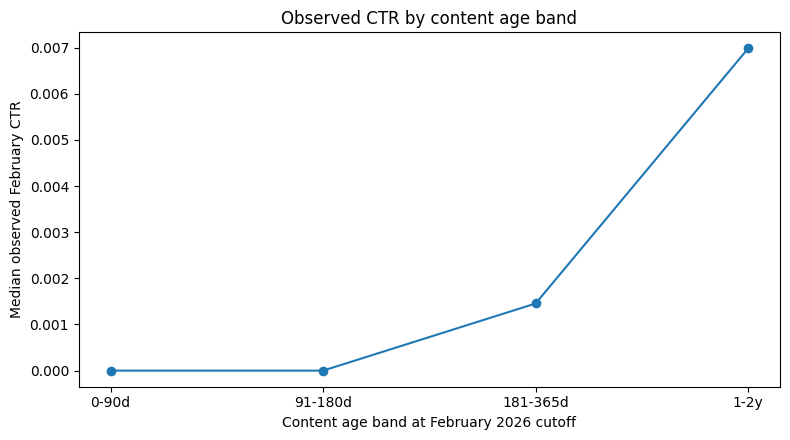

Saved: work/figures/ctr_by_content_age.png

Interpretation rule: describe the pattern as observed/directional only. Do not claim that age causes CTR decline or that refreshing content will cause improvement.


In [8]:
# Reusable figure for the paper: age band vs observed February CTR.
plot_df = age_summary.dropna(subset=["median_ctr"]).copy()

plt.figure(figsize=(8, 4.5))
plt.plot(
    plot_df["age_band"].astype(str),
    plot_df["median_ctr"],
    marker="o"
)
plt.xlabel("Content age band at February 2026 cutoff")
plt.ylabel("Median observed February CTR")
plt.title("Observed CTR by content age band")
plt.tight_layout()

figure_path = "work/figures/ctr_by_content_age.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

print(
    "\nInterpretation rule: describe the pattern as observed/directional only. "
    "Do not claim that age causes CTR decline or that refreshing content will cause improvement."
)

### Practical decay/refresh interpretation

Use the age analysis as a **triage context**, not a trigger:

- If an older age band has lower measured CTR, it can support a **review question** about staleness or query/page alignment.
- It should **not** automatically trigger a refresh.
- A refresh decision should also consider impression volume, position, business importance, recent changes, and human review.
- If age bands are flat or inconsistent, do not manufacture a decay story.

The strongest safe statement is: **“We observed a directional relationship between content age and measured CTR in this slice; this is decision-support evidence, not causal evidence that refreshing older content will improve CTR.”**

## 5. Intended use and limits

### Intended use

This playbook is intended to help a content/SEO team **prioritize a manageable review queue**.

It can answer:

> “Which measured content items look most worth investigating first, given their February search performance and the model's validated ranking signal?”

### Limits

- The model is trained on a specific February → March observation window.
- The target is a benchmark-relative proxy, not a direct measure of whether a content change will succeed.
- Client-grouped validation improves the honesty of the estimate, but it does not prove generalization to every future client or month.
- CTR is affected by search position and impression volume; the model does not establish causality.
- Pseudonymous warehouse data does not provide the reviewer with private query text, URLs, or client identity.
- Low-volume CTR estimates are noisy.
- The queue is not production automation and should not directly publish changes.

## 6. Human review rules + no-go list

### Human review rules

A reviewer should:

1. Confirm the page has enough measured impressions to justify attention.
2. Check whether the position tier makes the comparison meaningful.
3. Inspect the page/query context available to the organization.
4. Consider recent edits, seasonality, business importance, and known measurement gaps.
5. Record the final action separately from the model score.
6. Prefer a small test/change with measurable follow-up over assuming the model proves the fix.

### Do **not** automate

Do not automatically:

- rewrite titles or page content;
- publish, delete, redirect, or deindex pages;
- claim a refresh will improve rankings or CTR;
- treat the score as a causal recommendation;
- expose private queries, URLs, domains, client identities, or other restricted data;
- prioritize work solely because a page is old;
- override editorial, legal, brand, or subject-matter review.

## 7. Monitoring / retrain triggers

The playbook should be monitored lightly rather than retrained on a calendar without evidence.

### Review trigger

Re-run the validation audit when:

- a new monthly outcome window becomes available;
- the measured position/volume distribution shifts materially;
- the base rate changes materially;
- the ranking metric degrades relative to the frozen baseline;
- the content mix or client mix changes substantially.

### Retrain trigger

Consider retraining when repeated monthly validation shows that the ranking signal has weakened or the relationship between the decision-time features and future outcomes has shifted.

Do **not** retrain simply because a new month exists. Keep a reproducible validation comparison first.

## 8. Cost / value thinking

The score is useful only if review effort is scarce.

A simple prioritization principle is:

> **Expected decision value = evidence strength × potential value of investigating − review cost.**

The notebook does not estimate monetary ROI because the warehouse does not provide a defensible per-page intervention cost or incremental revenue outcome.

Therefore:

- use higher-volume opportunities when review capacity is limited;
- reserve deeper investigations for pages with enough evidence;
- treat low-volume/high-score rows cautiously;
- measure outcomes after human-approved changes rather than assuming the score represents value.

## 9. Exports for the research paper

The notebook exports:

- `work/outputs/content_action_playbook_queue.csv` — regenerated ranked held-out queue
- `work/outputs/content_action_playbook_metrics.json` — metric receipts
- `work/figures/ctr_by_content_age.png` — reusable descriptive figure

The queue CSV should remain out of git according to the repository's data-handling rules. The notebook regenerates it. The figure can be committed under `work/figures/`.

In [9]:
# Final export/self-check.
required_outputs = [
    "work/outputs/content_action_playbook_queue.csv",
    "work/outputs/content_action_playbook_metrics.json",
    "work/figures/ctr_by_content_age.png",
]

for path in required_outputs:
    assert os.path.exists(path), f"Missing export: {path}"

# Leakage guard: no future outcome or label-derived field may be used as a model feature.
for forbidden in [
    "future_ctr", "mar_impressions", "mar_clicks",
    "y", "trend_direction", "trend_pct"
]:
    assert forbidden not in FEATURES, f"Leakage feature detected: {forbidden}"

assert set(train.client_hash_id).isdisjoint(set(test.client_hash_id))
assert len(queue) == len(test)

print("=== ML-10 SELF-CHECK ===")
print("✓ Ranked held-out queue exported")
print("✓ Reason code + action exported")
print("✓ Client-grouped validation preserved")
print("✓ Future outcome not used as a model feature")
print("✓ Human review rules and no-go cases documented")
print("✓ Monitoring/retrain triggers documented")
print("✓ Cost/value limits documented")
print("✓ Age/refresh result framed as observed/directional, not causal")
print("✓ Paper-ready metrics and figure exported")
print("\nReady to save as work/notebooks/w07_action_playbook.ipynb")

=== ML-10 SELF-CHECK ===
✓ Ranked held-out queue exported
✓ Reason code + action exported
✓ Client-grouped validation preserved
✓ Future outcome not used as a model feature
✓ Human review rules and no-go cases documented
✓ Monitoring/retrain triggers documented
✓ Cost/value limits documented
✓ Age/refresh result framed as observed/directional, not causal
✓ Paper-ready metrics and figure exported

Ready to save as work/notebooks/w07_action_playbook.ipynb
